In [6]:
import pickle
import pandas as pd
import copy
import numpy as np
import scipy.stats as stats
import ast
import seaborn as sns
from matplotlib import colors
import matplotlib.pyplot as plt

from _helper_functions import cb
from _helper_functions import dprint
from _helper_functions import zipdf
from _helper_functions import quickfig

In [20]:
fn='supp/endf.perRepActivities.pd.df.pickle'

allDF=pd.read_pickle(fn).set_index('wt-enhancer-seq',drop=False)
allDF.head(1)

,enhancer-id,enhancer-sites,wt-enhancer-seq,abl-enhancer-seq,enhancer-dep-ets-gata-1,enhancer-dep-ets-gata-2,enhancer-dep-ets-gata-3,wt-pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15-log2-rescaled,wt-pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15-log2-rescaled,wt-pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15-log2-rescaled,abl-pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15-log2-rescaled,abl-pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15-log2-rescaled,abl-pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15-log2-rescaled
wt-enhancer-seq,,,,,,,,,,,,,
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,OLS:0,S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0,0,0,1.210796,-0.356547,1.214739,NaN,1.236959,0.979943


In [21]:
fn='supp/OlsEnSeq2Id.pydict.pickle'
with open(fn,'rb') as f: OlsEnSeq2Id=pickle.load(f)
dprint(OlsEnSeq2Id)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA Otx-a WT


In [22]:
fn='supp/OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f: OLSEnSeq2Name=pickle.load(f)
dprint(OLSEnSeq2Name)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6


In [23]:
OLSName2Seq={v:k for k,v in OLSEnSeq2Name.items()}
dprint(OLSName2Seq)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA


In [24]:
with open('supp/OLSName2SyntaxFamily-vary-aff.pydict.pickle','rb') as f:OLSName2SyntaxFamily=pickle.load(f)
with open('supp/SyntaxFamily2OLSName-vary-aff.pydict.pickle','rb') as f:SyntaxFamily2OLSName=pickle.load(f)
    

In [25]:
dprint(SyntaxFamily2OLSName)

L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6 {'L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6', 'L1-G2R-L2-E1F-L3-E2F-L4-G1R-L5-G3F-L6', 'L1-G1R-L2-E2F-L3-E1F-L4-G3R-L5-G2F-L6', 'L1-G2R-L2-E1F-L3-E2F-L4-G3R-L5-G1F-L6', 'L1-G3R-L2-E2F-L3-E1F-L4-G2R-L5-G1F-L6', 'L1-G1R-L2-E2F-L3-E1F-L4-G2R-L5-G3F-L6', 'L1-G3R-L2-E1F-L3-E2F-L4-G2R-L5-G1F-L6', 'L1-G3R-L2-E1F-L3-E2F-L4-G1R-L5-G2F-L6', 'L1-G2R-L2-E2F-L3-E1F-L4-G3R-L5-G1F-L6', 'L1-G1R-L2-E1F-L3-E2F-L4-G3R-L5-G2F-L6', 'L1-G3R-L2-E2F-L3-E1F-L4-G1R-L5-G2F-L6', 'L1-G2R-L2-E2F-L3-E1F-L4-G1R-L5-G3F-L6'}


In [26]:
dprint(OLSName2SyntaxFamily)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6


# start analysis of a particular replicate

In [27]:
repset=3
activityColumn=f'wt-pool-sumR/sumD-{repset}-filtNa-Dnotnull-minActFilt0.15-log2-rescaled'

thresholdToLabelPositives = 1
thresholdToLabelNegatives = 0
idxSet=set(allDF.index)

In [ ]:
## if running notebook for the first time

synFamilies=[]
allFuncEns=[]
allNonFuncEns=[]
enFuncCounts=[]
enNonfuncCounts=[]
SyntaxFamily2Info={} # number functional and nonfunctional

for synFam,synVariants in SyntaxFamily2OLSName.items():

    synFamActivities=[]
    for tfbsList in synVariants:
        
        en=OLSName2Seq[tfbsList]
        
        if en in idxSet:  activity=allDF.at[en,activityColumn]
        else:             activity=0
            
        synFamActivities.append(activity)
        
        
    nonFuncCounts=sum([i<=thresholdToLabelNegatives for i in synFamActivities])
    funcCounts   =sum([i>=thresholdToLabelPositives for i in synFamActivities])
    
    if funcCounts==12:      
        allFuncEns.append(synFam)
        
    if nonFuncCounts==12:   
        allNonFuncEns.append(synFam)
    
    enFuncCounts.append(funcCounts)
    enNonfuncCounts.append(nonFuncCounts)
    synFamilies.append(synFam)
    
    SyntaxFamily2Info[synFam]=(funcCounts,nonFuncCounts)
    

c2v={'syntax-family':synFamilies,'n-func':enFuncCounts,'n-inert':enNonfuncCounts,'n-func-inert-tuple':[(i,j) for i,j in zip(enFuncCounts,enNonfuncCounts)]}
famDF=pd.DataFrame(c2v)
famDF.head()

#famDF.to_csv(f'F03-Syntax-Families-byreps/REP{repset}_syntax-fam-table-real-data.tsv',index=None,sep='\t')

,syntax-family,n-func,n-inert,n-func-inert-tuple
0,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,5,2,"(5, 2)"
1,L1-GF-L2-EF-L3-EF-L4-GR-L5-GF-L6,3,1,"(3, 1)"
2,L1-GR-L2-EF-L3-EF-L4-GF-L5-GF-L6,2,2,"(2, 2)"
3,L1-GR-L2-EF-L3-EF-L4-GR-L5-GR-L6,2,1,"(2, 1)"
4,L1-GR-L2-ER-L3-EF-L4-GR-L5-GF-L6,4,3,"(4, 3)"


In [12]:
# if youve already run the notebook
famDF=pd.read_csv(f'F03-Syntax-Families-byreps/REP{repset}_syntax-fam-table-real-data.tsv',sep='\t')

In [29]:
Bin2RealCount={}

for nfunc,ninert in zipdf(famDF,['n-func','n-inert']):
    if (nfunc,ninert) not in Bin2RealCount:
        Bin2RealCount[nfunc,ninert]=0
    Bin2RealCount[nfunc,ninert]+=1
        

# Permute starting data to generate the null distribution for syntax family active:inert element ratios

In [30]:
# if running notebook for the first time

activityColumn=f'wt-pool-sumR/sumD-{repset}-filtNa-Dnotnull-minActFilt0.15-log2-rescaled'
thresholdToLabelPositives = 1
thresholdToLabelNegatives = 0
idxSet=set(allDF.index)

npermutations=100
for permuteIter in range(npermutations):
    
    print(permuteIter,end=',  ')
    
    permEnhancers=np.random.permutation(allDF['wt-enhancer-seq'])
    allDF['wt-enhancer-seq']=permEnhancers
    allDF=allDF.set_index('wt-enhancer-seq',drop=False)

    
    synFamilies=[]
    allFuncEns=[]
    allNonFuncEns=[]
    enFuncCounts=[]
    enNonfuncCounts=[]
    SyntaxFamily2Info={} # number functional and nonfunctional
    for synFam,synVariants in SyntaxFamily2OLSName.items():


        synFamActivities=[]
        for tfbsList in synVariants:
            en=OLSName2Seq[tfbsList]

            if en in idxSet:  activity=allDF.at[en,activityColumn]
            else:             activity=0

            synFamActivities.append(activity)


        nonFuncCounts=sum([i<=thresholdToLabelNegatives for i in synFamActivities])
        funcCounts   =sum([i>=thresholdToLabelPositives for i in synFamActivities])

        if funcCounts==12:      
            allFuncEns.append(synFam)

        if nonFuncCounts==12:   
            allNonFuncEns.append(synFam)

        enFuncCounts.append(funcCounts)
        enNonfuncCounts.append(nonFuncCounts)
        synFamilies.append(synFam)

        SyntaxFamily2Info[synFam]=(funcCounts,nonFuncCounts)


    # lc=0
    # for f,nf in zip(enFuncCounts,enNonfuncCounts):
    #     lc+=1
    #     if lc==20: break

    #     print(f,nf)

    famDF[f'n-func-inert-tuple-permute-{permuteIter}']=[(i,j) for i,j in zip(enFuncCounts,enNonfuncCounts)]

#famDF.to_pickle(f'F03-Syntax-Families-byreps/REP{repset}_syntax-family-analysis-table-with-permuted-data_numiters={npermutations}.pd.df.pickle')
#famDF.to_csv(   f'F03-Syntax-Families-byreps/REP{repset}_syntax-family-analysis-table-with-permuted-data_numiters={npermutations}.tsv',sep='\t',index=None)

0,  1,  2,  3,  4,  5,  6,  7,  8,  9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  

/var/folders/5z/t9ftk7ds7890nc05pq3sr3fc0000gn/T/ipykernel_17684/2391661476.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  famDF[f'n-func-inert-tuple-permute-{permuteIter}']=[(i,j) for i,j in zip(enFuncCounts,enNonfuncCounts)]


99,  

/var/folders/5z/t9ftk7ds7890nc05pq3sr3fc0000gn/T/ipykernel_17684/2391661476.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  famDF[f'n-func-inert-tuple-permute-{permuteIter}']=[(i,j) for i,j in zip(enFuncCounts,enNonfuncCounts)]


In [31]:
npermutations=100
#famDF=pd.read_pickle(f'F03-Syntax-Families-byreps/REP{repset}_syntax-family-analysis-table-with-permuted-data_numiters={npermutations}.pd.df.pickle')

In [17]:
famDF.head(1)

,syntax-family,n-func,n-inert,n-func-inert-tuple,n-func-inert-tuple-permute-0,n-func-inert-tuple-permute-1,n-func-inert-tuple-permute-2,n-func-inert-tuple-permute-3,n-func-inert-tuple-permute-4,n-func-inert-tuple-permute-5,...,n-func-inert-tuple-permute-90,n-func-inert-tuple-permute-91,n-func-inert-tuple-permute-92,n-func-inert-tuple-permute-93,n-func-inert-tuple-permute-94,n-func-inert-tuple-permute-95,n-func-inert-tuple-permute-96,n-func-inert-tuple-permute-97,n-func-inert-tuple-permute-98,n-func-inert-tuple-permute-99
0,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,5,2,"(5, 2)","(3, 0)","(2, 0)","(4, 1)","(3, 2)","(0, 5)","(0, 2)",...,"(6, 0)","(3, 4)","(2, 2)","(4, 0)","(3, 0)","(2, 1)","(2, 1)","(1, 4)","(1, 1)","(2, 3)"


In [18]:
# z-normalize counts 

# get raw ccounts
Bin2NullCountList={}

for col in [ci for ci in famDF.columns if 'n-func-inert-tuple-permute' in ci]:
    
    bin2count={bi : famDF[col].tolist().count(bi) for bi in famDF[col].unique()}
    
    for bi,count in bin2count.items():
        if bi not in Bin2NullCountList:
            Bin2NullCountList[bi]=[]
        Bin2NullCountList[bi].append(count)
            
dprint(Bin2NullCountList,1)
print()

(3, 0) [1786, 1940, 1839, 1821, 1902, 1906, 1871, 1784, 1833, 1905, 1806, 1867, 1861, 1897, 1792, 1809, 1798, 1883, 1789, 1817, 1860, 1826, 1822, 1791, 1804, 1784, 1841, 1854, 1809, 1823, 1817, 1839, 1839, 1818, 1891, 1812, 1826, 1806, 1819, 1792, 1861, 1870, 1755, 1893, 1903, 1820, 1813, 1815, 1780, 1825, 1811, 1871, 1836, 1786, 1844, 1860, 1887, 1860, 1858, 1872, 1854, 1817, 1892, 1796, 1833, 1872, 1749, 1802, 1790, 1795, 1804, 1871, 1831, 1881, 1836, 1889, 1834, 1842, 1835, 1797, 1869, 1845, 1773, 1822, 1793, 1845, 1781, 1820, 1820, 1762, 1820, 1850, 1882, 1818, 1843, 1803, 1820, 1826, 1849, 1853]
(3, 2) [2529, 2486, 2387, 2406, 2408, 2516, 2361, 2444, 2470, 2458, 2557, 2484, 2486, 2522, 2487, 2505, 2489, 2461, 2457, 2478, 2400, 2509, 2498, 2520, 2547, 2445, 2494, 2442, 2438, 2431, 2511, 2442, 2395, 2443, 2405, 2399, 2473, 2489, 2477, 2563, 2558, 2512, 2479, 2475, 2461, 2437, 2511, 2456, 2542, 2470, 2510, 2472, 2418, 2496, 2545, 2451, 2468, 2548, 2504, 2445, 2474, 2476, 2523, 2507, 

In [33]:
allBins=set()
for i in range(0,13):
    for j in range(0,13):
        if i+j<=12:
            allBins.add((i,j))
            allBins.add((j,i))
            
# allBins

In [20]:
realBinsDetected=set(famDF['n-func-inert-tuple'].unique())
permutedBinsDetected=set(Bin2NullCountList.keys())

undetectedBins=allBins-realBinsDetected-permutedBinsDetected
undetectedBins

{(0, 10),
 (0, 11),
 (0, 12),
 (1, 10),
 (1, 11),
 (2, 9),
 (2, 10),
 (3, 9),
 (8, 4),
 (10, 2),
 (11, 1),
 (12, 0)}

In [35]:
# get z normalizing info

Bin2Info={bi:{'std':np.std(Bin2NullCountList[bi]), 'mean':np.mean(Bin2NullCountList[bi]), 'median':np.median(Bin2NullCountList[bi])} for bi in Bin2NullCountList}

dprint(Bin2Info,5)

print()

#  z  normalize real data

Bin2RealZ={}

bin2realcount={bi : famDF['n-func-inert-tuple'].tolist().count(bi) for bi in famDF['n-func-inert-tuple'].unique()}
# bin2realcount={ast.literal_eval(bi) : famDF['n-func-inert-tuple'].tolist().count(bi) for bi in famDF['n-func-inert-tuple'].unique()}

for bi in famDF['n-func-inert-tuple'].unique():

    if type(bi)==str: ast.literal_eval(bi)

    # if bin has data from permuted in it (not all do)
    if bi not in Bin2Info:
        Bin2RealZ[bi]=np.inf
        
    else:
        Bin2RealZ[bi] = ( bin2realcount[bi] - Bin2Info[bi]['mean'] ) / Bin2Info[bi]['std']
        

(1, 3) {'std': 35.165714837039786, 'mean': 1371.35, 'median': 1371.0}
(2, 1) {'std': 59.64459405511953, 'mean': 3599.32, 'median': 3602.5}
(2, 2) {'std': 49.293337277972974, 'mean': 3145.13, 'median': 3147.0}
(0, 3) {'std': 22.187284646842212, 'mean': 515.62, 'median': 517.5}
(3, 2) {'std': 37.42215787471374, 'mean': 2477.11, 'median': 2475.0}
(3, 1) {'std': 50.688771932253395, 'mean': 3188.78, 'median': 3184.5}



/var/folders/5z/t9ftk7ds7890nc05pq3sr3fc0000gn/T/ipykernel_17684/1894192903.py:25: RuntimeWarning: divide by zero encountered in scalar divide
  Bin2RealZ[bi] = ( bin2realcount[bi] - Bin2Info[bi]['mean'] ) / Bin2Info[bi]['std']


In [36]:
# replace nan with max  Z
maxz=max([i for i in Bin2RealZ.values() if  i!=np.inf])
for bi,zi in Bin2RealZ.items():
    if zi==np.inf:
        Bin2RealZ[bi]=maxz
        
print(maxz)
dprint(Bin2RealZ,5)    

69.04602208326344
(5, 2) 1.3330906041613109
(3, 1) -14.318358333281784
(2, 2) -7.914457035034876
(2, 1) -7.95243906868853
(4, 3) -5.369838946267269
(4, 2) -5.6213309901678015


In [37]:
minz=min(Bin2RealZ.values())


In [38]:
Bin2RealP={(yi,xi):stats.norm.sf(abs(zi))*2 for (yi,xi),zi in Bin2RealZ.items()}
minp=min([i for i in Bin2RealP.values() if i>0])
Bin2RealP={(yi,xi):pi if pi>0 else minp for (yi,xi),pi in Bin2RealP.items()}



In [39]:
Bin2RealPAdj={(yi,xi):pi*len(Bin2RealP) for (yi,xi),pi in Bin2RealP.items()}
# Bin2RealPAdj

In [40]:

ninertlist=[]
nfunclist=[]

for bi in Bin2Info:
    numOccurences=int(Bin2Info[bi]['mean'])
    nfunc=bi[0]
    ninert=bi[1]
    
    for i in range(numOccurences):
        nfunclist.append(nfunc)
        ninertlist.append(ninert)
        

/scratch/solvason/job_5990576/ipykernel_3225253/625161779.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  heatmap1, xedges1, yedges1, im1 = ax[0].hist2d(x=famDF['n-inert'],y=famDF['n-func'],bins=range(15),cmap=plt.cm.get_cmap('rainbow'),cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax)#
/scratch/solvason/job_5990576/ipykernel_3225253/625161779.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  heatmap2, xedges2, yedges2, im2 = ax[1].hist2d(x=ninertlist,y=nfunclist,bins=(xedges1, yedges1), cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax,cmap=plt.cm.get_cmap('rainbow'))


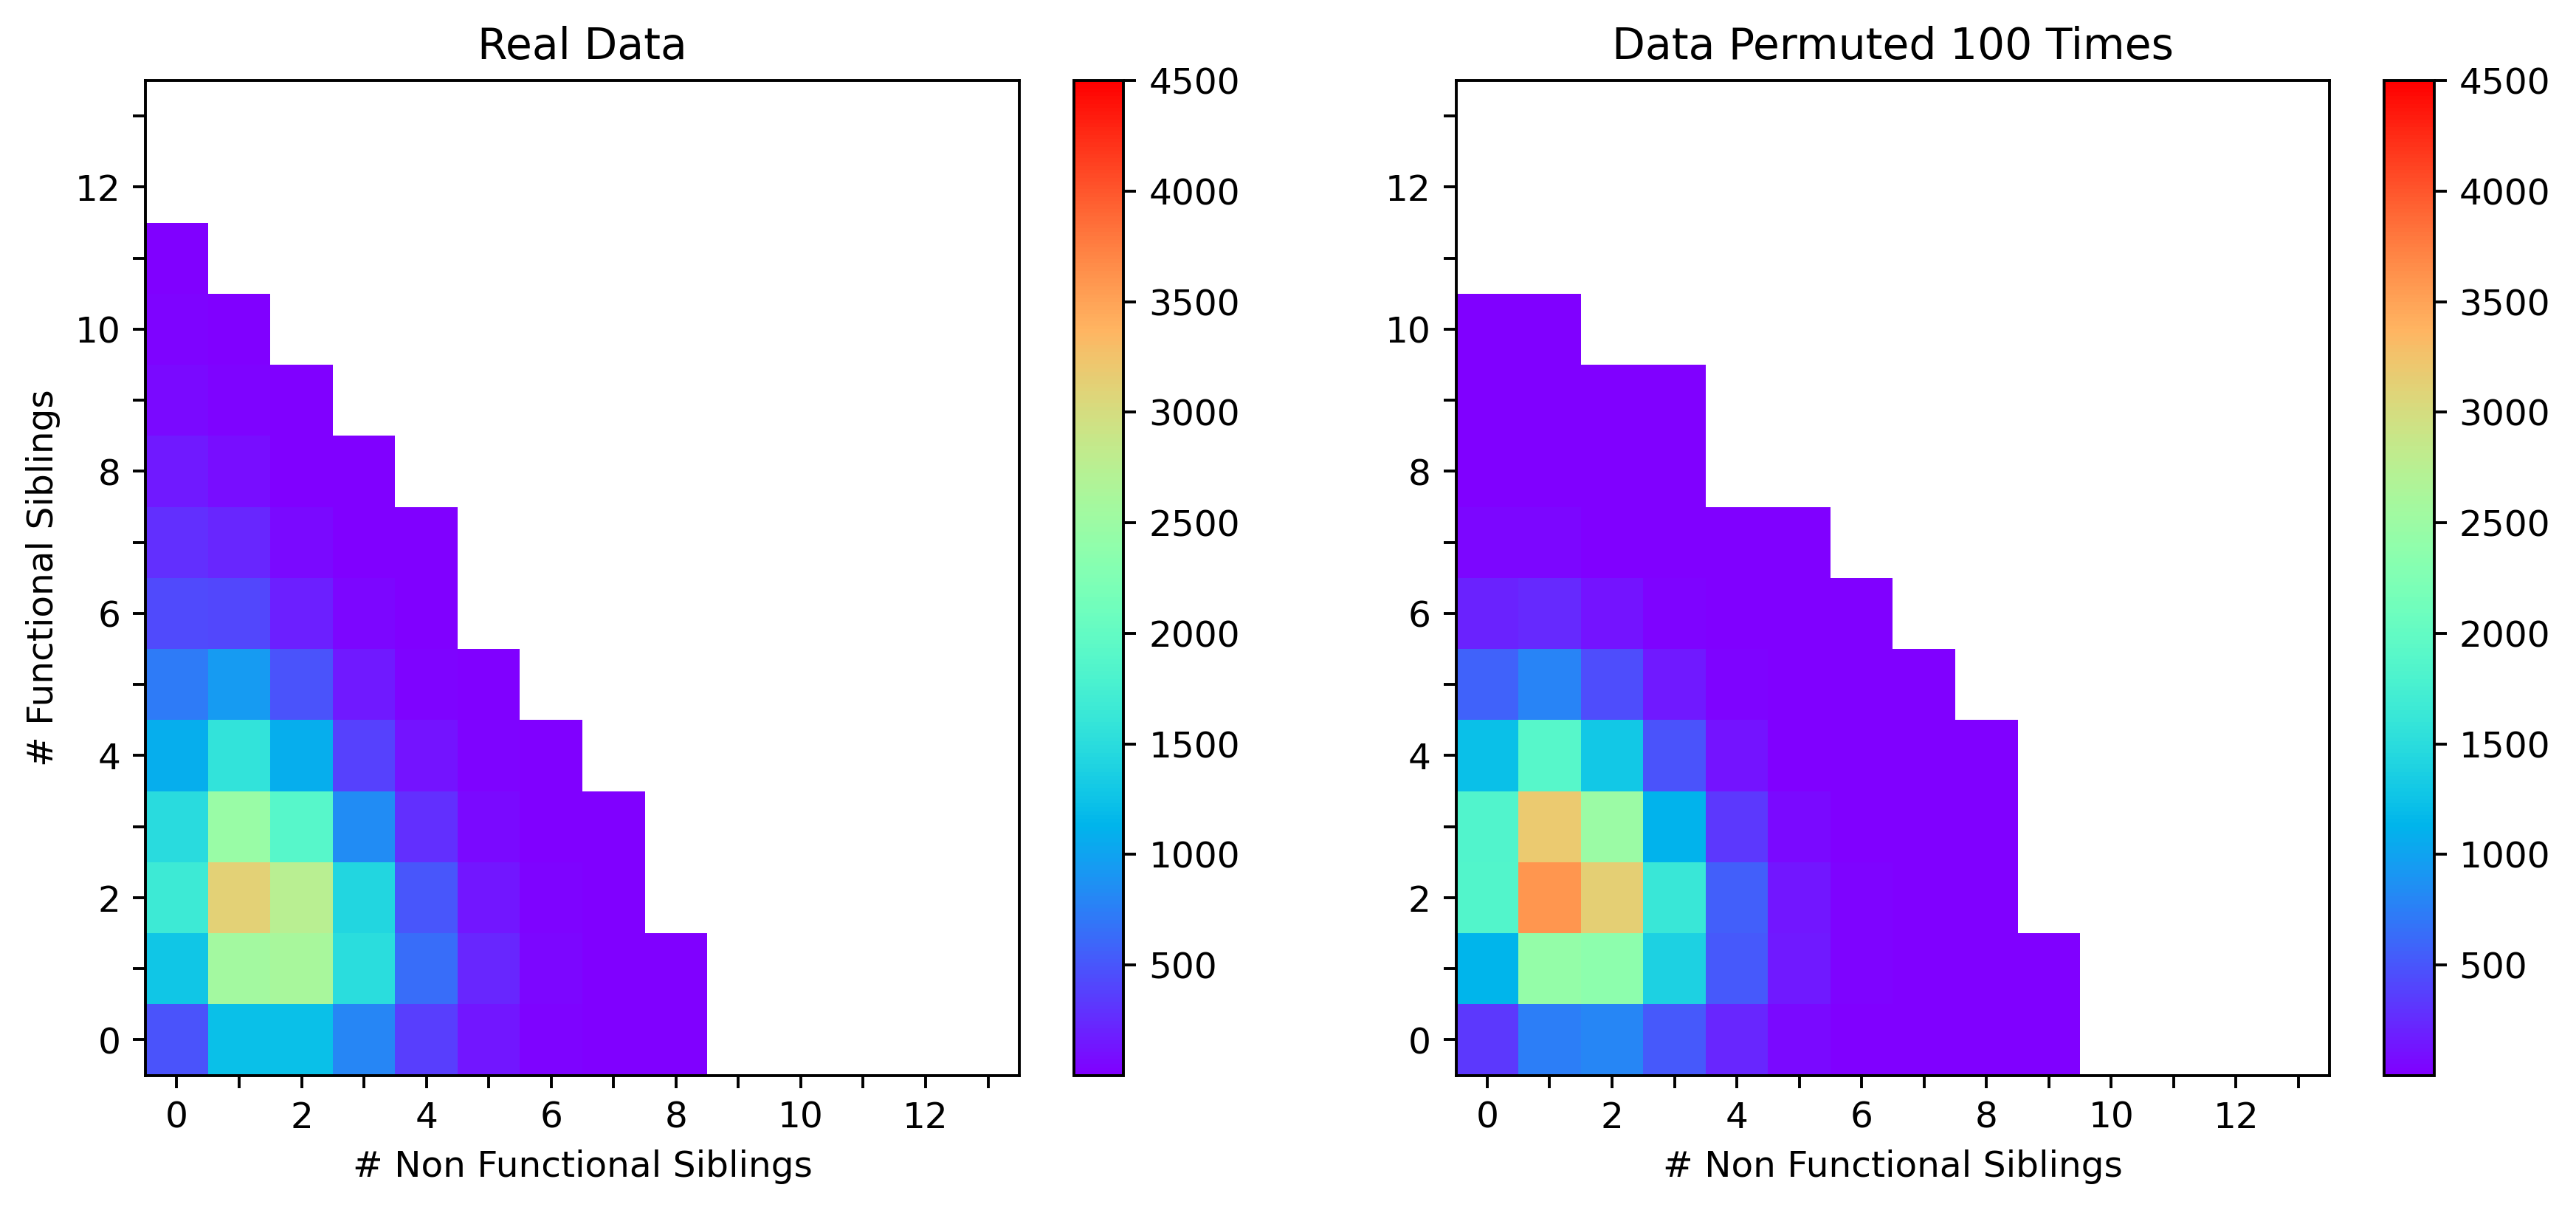

In [29]:
 
vmin=1
vmax=4500
cmin=vmin
cmax=vmax

fig,ax=plt.subplots(1, 2, figsize=(12, 5),dpi=350)

heatmap1, xedges1, yedges1, im1 = ax[0].hist2d(x=famDF['n-inert'],y=famDF['n-func'],bins=range(15),cmap=plt.cm.get_cmap('rainbow'),cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax)#

fig.colorbar(im1, ax=ax[0], orientation='vertical')        


ax[0].set_ylabel('# Functional Siblings')
ax[0].set_xlabel('# Non Functional Siblings')
ax[0].set_title('Real Data')

heatmap2, xedges2, yedges2, im2 = ax[1].hist2d(x=ninertlist,y=nfunclist,bins=(xedges1, yedges1), cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax,cmap=plt.cm.get_cmap('rainbow'))

ax[1].set_xlabel('# Non Functional Siblings')
ax[1].set_title(f'Data Permuted {npermutations} Times')


fig.colorbar(im1, ax=ax[1], orientation='vertical')        

for i in [0,1]:
    ticks=range(14)
    ax[i].set_yticks([t+.5 for t in ticks],labels=[t if t%2==0 else '' for t in ticks])
    ax[i].set_xticks([t+.5 for t in ticks],labels=[t if t%2==0 else '' for t in ticks])
        


In [42]:
with open('supp/syntax-fam-Bin2Annotation.pydict.pickle','rb') as f: 
    Bin2Annotation=pickle.load(f)

In [43]:
Annotation2Bins={anno:set() for anno in set(Bin2Annotation.values())}

for b,a in Bin2Annotation.items():
    
    Annotation2Bins[a].add(b)
    

In [44]:
anno2color={
    "":"white",
    "Inert":cb['orangenature'],
    "Moderate":'darkgrey',
    "Robust":cb['green'],
}


 	 16,451
Robust 	 516
Inert 	 10
Moderate 	 21,423


(-1.0, 13.0)

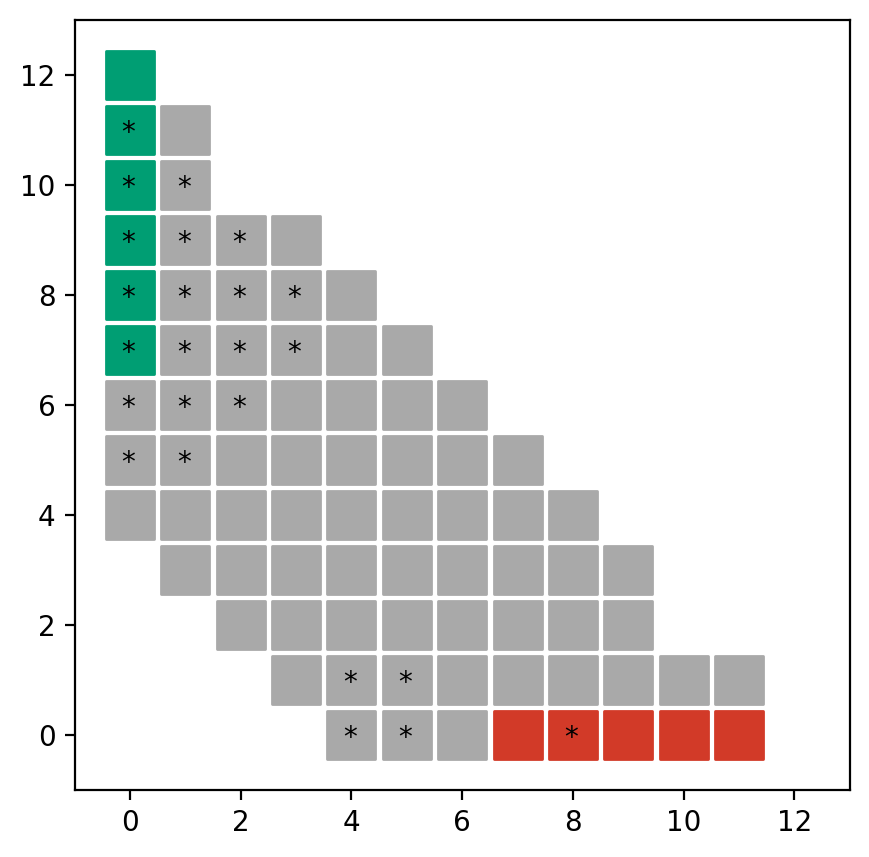

In [39]:
fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)

for y,x in Bin2Annotation:
    anno=Bin2Annotation[y,x]
    color=anno2color[anno]
    
    ax.scatter(x,y,marker='s',color=color,s=300)
    
    if ((y,x) not in Bin2RealPAdj) or (anno==''): 
        p=1
        c=''

    else:                         
        p=Bin2RealPAdj[y,x]
        c=Bin2RealCount[y,x]
        if c>=1000:
            c=round(c/1000)
            c=f'{c}k'
    
    if p<1e-5 and Bin2RealZ[y,x]>0: ax.text(x-.03,y-.06,'*',ha='center',va='center')
    
for anno,bins in Annotation2Bins.items():
    
    count=0
    for b in bins:
        if b not in Bin2RealCount: continue
        count+=Bin2RealCount[b]
        
    print(anno,'\t',f'{count:,}')
    
    
ax.set_ylim(-1,13)
ax.set_xlim(-1,13)
